# CSCE 676 Final Project
## Sequential Patterns vs. Basket-Based Co-Occurrence in OTTO Session Data

**Name:** Bhaumik Patel  
**UIN:** 737002364  
**Course:** CSCE 676 Data Mining and Analysis

This notebook is the clean final story of the project: motivation, research question, results, analysis, and conclusion.



## Project Journey: From Dataset Selection to Final Question

This notebook is the final deliverable for CSCE 676. To give the full context, this section briefly recaps the two checkpoints that led here — the decisions made, what was learned, and why the final direction took the shape it did.

---

### Checkpoint 1 — Dataset Selection and Initial EDA

The first checkpoint began with a structured comparison of three candidate datasets:

- **OTTO Recommender Systems Dataset** — a large-scale e-commerce session log with time-ordered clicks, carts, and orders from a real Kaggle competition.
- **OGB-Products** — a graph-based product co-purchasing dataset designed for node property prediction.
- **CIC-IDS-2017** — a network intrusion detection dataset with labeled attack traffic.

OTTO was selected because it offered the strongest alignment with both course techniques and beyond-course extension. Each session is a natural transaction basket, making it directly compatible with FP-Growth and association rule mining. But crucially, the dataset also preserves event order and action types — clicks, carts, orders — which opens the door to sequential pattern mining. That dual compatibility made it possible to study both representations on the same data, which is the core of this project.

The initial EDA was conducted on a **20,000-session random sample**. Key findings from that first look: interactions were heavily dominated by clicks, session lengths were strongly right-skewed, and item popularity followed a long-tail distribution. A feasibility check confirmed that both FP-Growth and PrefixSpan could run on sampled OTTO data without memory or runtime issues.

---

### Checkpoint 2 — Research Question Formation and Extended EDA

The second checkpoint refined the project direction and deepened the exploratory analysis in three ways.

First, the research question was sharpened. Three candidate questions were evaluated:
1. How does minimum support affect frequent itemsets?
2. How do confidence and lift affect association rule quality?
3. Do sequential patterns reveal behavioral structure that unordered basket methods miss?

Questions 1 and 2 were recognized as supporting analyses within the basket framework. Question 3 was chosen as the project headline because it directly tests whether the choice of data representation — basket vs sequence — changes what can be learned. That is the question this notebook answers.

Second, a **full streaming scan of the 11GB training file** was added to ground the analysis in real dataset statistics rather than sample estimates alone. That scan produced the whole-dataset numbers used in Section 1 of this notebook: 12.9 million sessions, 216 million events, 1.8 million unique items.

Third, preliminary feasibility experiments confirmed the comparison plan: FP-Growth produced frequent itemsets and association rules on sampled data, a basket sparsity diagnostic showed that co-occurrence is thin even at low support thresholds, and a preliminary overlap check between FP-Growth pairs and PrefixSpan patterns gave early evidence that the two methods find related but structurally different information.

This notebook is the clean, final version of that story — no dead ends, no trial runs, just the coherent argument built from those two checkpoints forward.

---

## Motivation and Final Research Question

OTTO is ideal for this project because it preserves **time-ordered e-commerce sessions** with `clicks`, `carts`, and `orders`. That creates two valid representations of the same data:

1. **Basket view:** unordered co-occurrence of items.
2. **Sequence view:** ordered user behavior through time.

### Final research question
**Do sequence-aware methods reveal high-intent behavioral structure in OTTO session logs that basket-based frequent itemsets and association rules fail to capture?**

### Why this question, and not the others?
I considered three related questions:
- how minimum support changes frequent itemsets;
- how confidence and lift change rule rankings;
- whether sequential patterns reveal structure that baskets miss.

I chose the third question as the project headline because it best matches both the OTTO data and the course trajectory. The first two are important, but they are ultimately **supporting analyses inside the basket framework**. The final question is stronger because it directly asks whether preserving order changes what we can learn.


In [1]:
from __future__ import annotations
import itertools, json, pickle, random
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from mlxtend.frequent_patterns import association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

BASE = Path.cwd()
TRAIN = BASE / "otto-recsys-train.jsonl"
FULL_CACHE = BASE / "otto_full_scan_summary.json"
SAMPLE_CACHE = BASE / "otto_sample_20k.pkl"
SAMPLE_N = 20_000
SEED = 42
MIN_ITEM_SUPPORT = 20
MIN_SUPPORTS = [0.0010, 0.0015, 0.0020, 0.0030]
CHOSEN_SUPPORT = 0.0015
if not TRAIN.exists():
    print(f"Warning: {TRAIN} not found. Using cached artifacts when available.")

def reservoir_sample_jsonl(path, sample_size, seed=42):
    random.seed(seed)
    reservoir = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            if i < sample_size:
                reservoir.append(obj)
            else:
                j = random.randint(0, i)
                if j < sample_size:
                    reservoir[j] = obj
    return reservoir

def load_sample():
    if SAMPLE_CACHE.exists():
        return pickle.loads(SAMPLE_CACHE.read_bytes())
    sessions = reservoir_sample_jsonl(TRAIN, SAMPLE_N, SEED)
    SAMPLE_CACHE.write_bytes(pickle.dumps(sessions, protocol=pickle.HIGHEST_PROTOCOL))
    return sessions

def load_full_summary():
    return json.loads(FULL_CACHE.read_text(encoding="utf-8"))

def flatten(sessions):
    rows=[]
    for s in sessions:
        sid=s["session"]
        for e in s["events"]:
            rows.append({"session":sid,"aid":int(e["aid"]),"ts":e["ts"],"type":e["type"]})
    df=pd.DataFrame(rows)
    df["ts"]=pd.to_datetime(df["ts"], unit="ms")
    return df.sort_values(["session","ts"]).reset_index(drop=True)

def first_occurrence(vals):
    out=[]; seen=set()
    for v in vals:
        if v not in seen:
            out.append(v); seen.add(v)
    return out

def set_str(vals):
    return " | ".join(sorted(map(str, vals)))

def contains_subseq(seq, pat):
    j=0
    for x in seq:
        if x==pat[j]:
            j+=1
            if j==len(pat):
                return True
    return False


## 1. Full-Dataset Motivation

I begin by grounding the project in the **entire OTTO training set**. This matters because support, sparsity, and interpretability all depend on the real dataset shape, not only on a small sample. The summary below is loaded from a cache created by a full streaming scan of the 11GB training file.


,metric,value
0,Sessions,"12,899,779.0000"
1,Events,"216,716,096.0000"
2,Unique items,"1,855,603.0000"
3,Mean session length,16.8000
4,Median session length,6.0000
5,95th pct length,68.0000
6,99th pct length,176.0000
7,Top-10 item share (%),0.4700
8,Top-1% item share (%),38.2100


,event_type,count,percent
0,clicks,194720954,89.8507
1,carts,16896191,7.7965
2,orders,5098951,2.3528


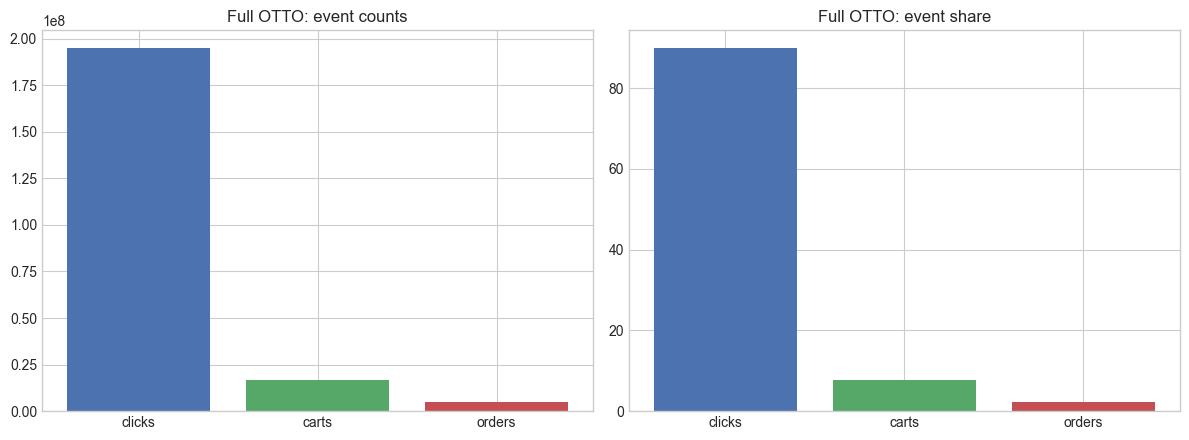

In [2]:
full = load_full_summary()
full_df = pd.DataFrame({
    "metric":["Sessions","Events","Unique items","Mean session length","Median session length","95th pct length","99th pct length","Top-10 item share (%)","Top-1% item share (%)"],
    "value":[
        full["n_sessions"], full["n_events"], full["n_items"],
        round(full["session_length_summary"]["mean"],2), round(full["session_length_summary"]["median"],2),
        round(full["session_length_summary"]["p95"],2), round(full["session_length_summary"]["p99"],2),
        round(100*full["top10_share"],2), round(100*full["top1pct_share"],2)
    ]
})
event_df = pd.DataFrame({
    "event_type": list(full["event_type_counts"].keys()),
    "count": list(full["event_type_counts"].values()),
    "percent": [100*full["event_type_props"][k] for k in full["event_type_counts"]]
}).sort_values("count", ascending=False)
display(full_df)
display(event_df)
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].bar(event_df["event_type"], event_df["count"], color=["#4C72B0", "#55A868", "#C44E52"])
ax[0].set_title("Full OTTO: event counts")
ax[1].bar(event_df["event_type"], event_df["percent"], color=["#4C72B0", "#55A868", "#C44E52"])
ax[1].set_title("Full OTTO: event share")
plt.tight_layout(); plt.show()


The full scan immediately shows why this is a good sequence-mining problem: the catalog is **extremely long-tailed**, clicks dominate behavior, and session lengths are strongly skewed. Those properties make basket mining informative but incomplete. 


## 2. Representative Sample and Dual Representation

For the mining experiments, I use a **uniform random sample of 20,000 sessions**. Then I build two views of the same sample:
- a **basket view** of unique items per session;
- a **sequence view** based on the **first occurrence** of each frequent item in session order.

Because OTTO is so sparse, I keep only items that appear in at least **20 sampled sessions**. This keeps the recurring-item subproblem interpretable and computationally stable.


,metric,value
0,Sample sessions,"20,000.0000"
1,Sample events,"338,549.0000"
2,Unique sample items,"127,120.0000"
3,Mean session length,16.9300
4,Median session length,6.0000
5,Sessions with cart (%),29.4300
6,Sessions with order (%),12.4600
7,Sessions ending with order (%),4.4000


,quantity,value
0,Frequent items,362.0000
1,Sessions with >=1 frequent item,"5,248.0000"
2,Coverage of sample (%),26.2400
3,Average filtered basket length,2.1400
4,Average first-occurrence sequence length,2.1400


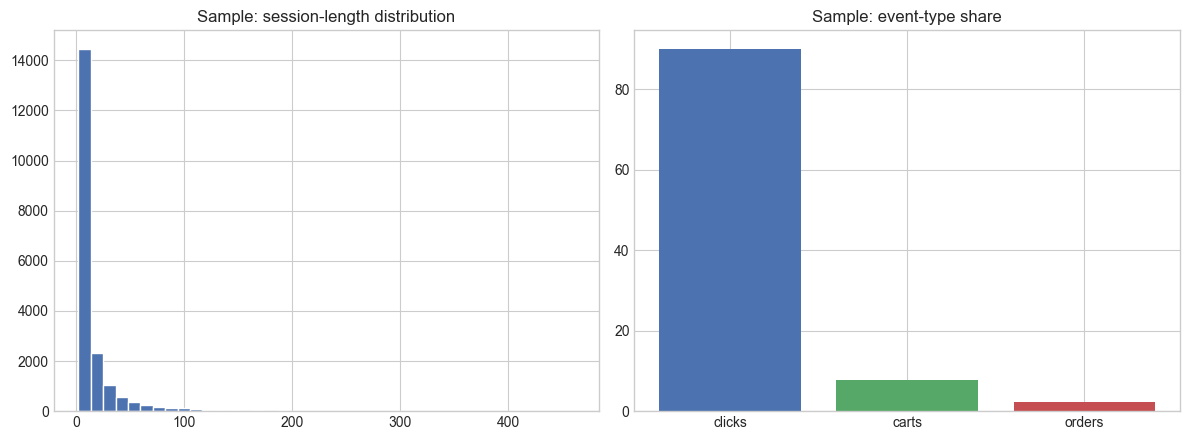

In [3]:
sessions = load_sample()
df = flatten(sessions)
lengths = df.groupby("session").size()
sample_df = pd.DataFrame({
    "metric":["Sample sessions","Sample events","Unique sample items","Mean session length","Median session length","Sessions with cart (%)","Sessions with order (%)","Sessions ending with order (%)"],
    "value":[
        len(sessions), len(df), df["aid"].nunique(), round(lengths.mean(),2), round(lengths.median(),2),
        round(100*np.mean([any(e["type"]=="carts" for e in s["events"]) for s in sessions]),2),
        round(100*np.mean([any(e["type"]=="orders" for e in s["events"]) for s in sessions]),2),
        round(100*np.mean([s["events"][-1]["type"]=="orders" for s in sessions]),2)
    ]
})
display(sample_df)

basket_raw = df.groupby("session")["aid"].apply(lambda x: list(pd.unique(x))).to_dict()
item_support = Counter(); [item_support.update(set(b)) for b in basket_raw.values()]
keep = {aid for aid,c in item_support.items() if c >= MIN_ITEM_SUPPORT}
baskets = {sid:[str(a) for a in b if a in keep] for sid,b in basket_raw.items()}
baskets = {sid:b for sid,b in baskets.items() if b}
seqs = {}
for sid, g in df.groupby("session"):
    filt = [str(a) for a in g["aid"].tolist() if a in keep]
    seqs[sid] = first_occurrence(filt)
seqs = {sid:s for sid,s in seqs.items() if s}
repr_df = pd.DataFrame({
    "quantity":["Frequent items","Sessions with >=1 frequent item","Coverage of sample (%)","Average filtered basket length","Average first-occurrence sequence length"],
    "value":[len(keep), len(baskets), round(100*len(baskets)/SAMPLE_N,2), round(np.mean([len(v) for v in baskets.values()]),2), round(np.mean([len(v) for v in seqs.values()]),2)]
})
display(repr_df)
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].hist(lengths, bins=40, color="#4C72B0", edgecolor="white")
ax[0].set_title("Sample: session-length distribution")
ax[1].bar(df["type"].value_counts().index, 100*df["type"].value_counts(normalize=True).values, color=["#4C72B0", "#55A868", "#C44E52"])
ax[1].set_title("Sample: event-type share")
plt.tight_layout(); plt.show()


This representation step is an important project decision. The basket analysis below should be read as **co-occurrence structure among recurring items**, while the sequence analysis asks whether those same sessions carry directional or conversion-related structure that baskets erase.

The threshold of 20 sessions is chosen to retain items that recur meaningfully 
across the sample rather than appearing by chance — below this threshold, 
co-occurrence counts are too small to distinguish signal from noise at any 
reasonable support level. This reduces 127,120 unique sample items down to 362 
frequent ones, which is the working vocabulary for all mining experiments.

First-occurrence deduplication is chosen over full-sequence inclusion because 
it prevents high-frequency popular items from dominating sequence support through 
repetition within a single session — the goal is to capture which items a user 
visited and in what order, not how many times they revisited each one.


## 3. Course Baseline: Frequent Itemsets and Association Rules

I use **FP-Growth** as the basket baseline. This section serves two purposes:
1. answer the support-threshold question as a supporting analysis;
2. build the association-rule baseline before moving to the sequence-aware comparison.

This choice is intentional. OTTO has a **long-tail item distribution** and an extremely sparse basket space, which means naive candidate generation becomes unattractive very quickly. In that setting, **FP-Growth is more appropriate than Apriori** because it compresses recurring structure into an FP-tree and avoids repeatedly enumerating huge numbers of low-support candidates. The trade-off is that basket mining is still fundamentally an unordered view of behavior: it is good for discovering co-occurrence, affinity, and rule strength, but it is not designed to represent how users move from browsing to purchase. That is why the basket section is the baseline rather than the final answer.


C:\Users\Bhaumik\AppData\Local\Temp\ipykernel_11412\1660362398.py:3: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  tx = pd.DataFrame.sparse.from_spmatrix(mat, columns=enc.columns_)


,min_support,total_itemsets,singletons,pairs,triples
0,0.0010,738,362,343,33
1,0.0015,511,362,145,4
2,0.0020,414,362,52,0
3,0.0030,375,362,13,0


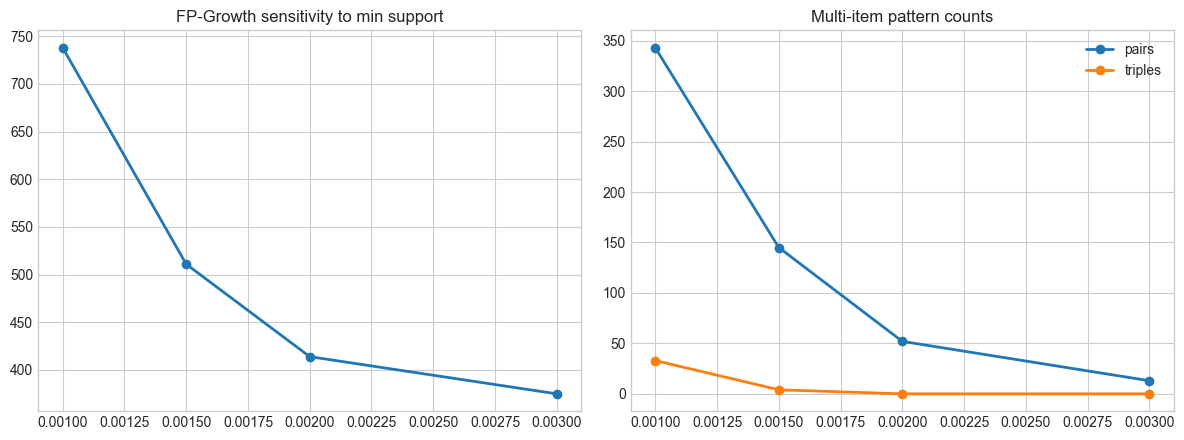

Chosen support: 0.0015


,itemset,length,support_count,support
388,231487 | 756588 | 77440,3,9,0.0017
383,108125 | 24318 | 933576,3,8,0.0015
392,1383529 | 231487 | 756588,3,8,0.0015
407,108125 | 435253 | 659399,3,8,0.0015
429,231487 | 756588,2,25,0.0048
438,29735 | 832192,2,23,0.0044
401,108125 | 435253,2,20,0.0038
400,108125 | 612920,2,19,0.0036
386,756588 | 77440,2,18,0.0034
366,1460571 | 811371,2,17,0.0032


Rule counts by confidence threshold


,min_confidence,rule_count
0,0.1000,303
1,0.2000,213
2,0.3000,129
3,0.5000,22


Top rules by confidence


,antecedent,consequent,support_count,support,confidence,lift
66,1383529 | 231487,756588,8,0.0015,0.8889,64.7901
42,24318 | 933576,108125,8,0.0015,0.8889,40.2146
40,108125 | 933576,24318,8,0.0015,0.7273,131.6113
101,435253 | 659399,108125,8,0.0015,0.7273,32.9028
156,1436280,832192,16,0.0030,0.6400,53.3130
152,823143,1733943,16,0.0030,0.6400,40.9600
247,49928,184976,14,0.0027,0.6364,42.8159
65,1383529 | 756588,231487,8,0.0015,0.6154,42.4939
246,7651,108125,17,0.0032,0.6071,27.4680
88,435253,108125,20,0.0038,0.5882,26.6126


Top rules by lift


,antecedent,consequent,support_count,support,confidence,lift
40,108125 | 933576,24318,8,0.0015,0.7273,131.6113
44,24318,108125 | 933576,8,0.0015,0.2759,131.6113
41,108125 | 24318,933576,8,0.0015,0.5000,131.2000
43,933576,108125 | 24318,8,0.0015,0.4000,131.2000
149,695107,631899,10,0.0019,0.4762,113.5931
148,631899,695107,10,0.0019,0.4545,113.5931
30,787236,1832623,10,0.0019,0.4348,95.0725
29,1832623,787236,10,0.0019,0.4167,95.0725
176,271231,664490,8,0.0015,0.4000,91.2696
297,51144,1632206,8,0.0015,0.4000,91.2696


In [4]:
enc = TransactionEncoder()
mat = enc.fit(list(baskets.values())).transform(list(baskets.values()), sparse=True)
tx = pd.DataFrame.sparse.from_spmatrix(mat, columns=enc.columns_)
itemsets_by_support = {}
rows = []
for ms in MIN_SUPPORTS:
    itemsets = fpgrowth(tx, min_support=ms, use_colnames=True)
    itemsets["length"] = itemsets["itemsets"].map(len)
    itemsets["support_count"] = (itemsets["support"] * len(tx)).round().astype(int)
    itemsets_by_support[ms] = itemsets.copy()
    rows.append({
        "min_support": ms,
        "total_itemsets": len(itemsets),
        "singletons": int((itemsets["length"]==1).sum()),
        "pairs": int((itemsets["length"]==2).sum()),
        "triples": int((itemsets["length"]==3).sum())
    })

sweep = pd.DataFrame(rows)
display(sweep)
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].plot(sweep["min_support"], sweep["total_itemsets"], marker="o", linewidth=2)
ax[0].set_title("FP-Growth sensitivity to min support")
ax[1].plot(sweep["min_support"], sweep["pairs"], marker="o", label="pairs", linewidth=2)
ax[1].plot(sweep["min_support"], sweep["triples"], marker="o", label="triples", linewidth=2)
ax[1].legend(); ax[1].set_title("Multi-item pattern counts")
plt.tight_layout(); plt.show()

itemsets = itemsets_by_support[CHOSEN_SUPPORT].copy()
itemsets["itemset"] = itemsets["itemsets"].map(set_str)
itemsets_multi = itemsets[itemsets["length"]>=2].sort_values(["length","support","support_count"], ascending=[False,False,False])
print(f"Chosen support: {CHOSEN_SUPPORT}")
display(itemsets_multi[["itemset","length","support_count","support"]].head(20))

rule_counts=[]
for conf in [0.10,0.20,0.30,0.50]:
    rule_counts.append({"min_confidence":conf, "rule_count": len(association_rules(itemsets, metric="confidence", min_threshold=conf))})
rule_counts = pd.DataFrame(rule_counts)
rules = association_rules(itemsets, metric="confidence", min_threshold=0.10).copy()
rules["support_count"] = (rules["support"] * len(tx)).round().astype(int)
rules["antecedent"] = rules["antecedents"].map(set_str)
rules["consequent"] = rules["consequents"].map(set_str)
conf_top = rules.sort_values(["confidence","lift","support_count"], ascending=[False,False,False])[["antecedent","consequent","support_count","support","confidence","lift"]].head(10)
lift_top = rules.sort_values(["lift","confidence","support_count"], ascending=[False,False,False])[["antecedent","consequent","support_count","support","confidence","lift"]].head(10)
print("Rule counts by confidence threshold")
display(rule_counts)
print("Top rules by confidence")
display(conf_top)
print("Top rules by lift")
display(lift_top)


### What the Basket Results Actually Show

The **support-threshold sweep** (min_support 0.0010 → 0.0030) reveals one of the most important properties of this dataset: **pattern counts collapse very quickly as support rises**. At 0.0010 we still find multi-item patterns, but by 0.0020 almost everything disappears except the most popular item co-occurrences. This is a direct consequence of the long-tail item distribution we saw in Section 1 — the top 1% of items capture 38% of events, meaning most items never accumulate enough co-occurrence to pass even a low support threshold. In practical terms: **basket mining on this data is best interpreted as discovering behavior among a small core of popular items, not as a general description of the catalog**.

The **top frequent itemsets** at support 0.0015 are dominated by 2-item pairs, with only a handful of 3-item sets surviving. That is expected given the sparsity, but it is worth stating: the itemsets that survive are the ones driven by popular-item gravity, not necessarily by meaningful user intent.

The **association rules** tell a more nuanced story. At confidence ≥ 0.10 we get 303 rules, but that number drops to 22 when we raise the bar to confidence ≥ 0.50. More importantly, **confidence and lift tell different things** about those rules. A rule with high confidence (like 0.89) means that nearly every session containing the antecedent also contains the consequent — but that may simply reflect that the consequent is a very common item. Lift corrects for that: a lift of 131 means the consequent is 131× more likely in sessions containing the antecedent than at random, which is a genuinely strong signal that these two items are linked beyond popularity. The rules with the **highest lift** in this dataset are also some of the most specific — small counts, rare items, but extremely non-random co-occurrence. Those are the most interesting rules analytically, even though they appear below the highest-confidence rules in a naive confidence-first sort.

However, all of this is still unordered. A rule like `{A} → {B}` with confidence 0.88 says nothing about whether A typically appears before or after B in a session. That is the gap this section exposes — and Section 4 is where we test whether filling that gap changes what we learn.


## 4. Beyond-Course Comparison: Sequence Structure That Baskets Hide

I now compare the basket view with a sequence-aware view in two concrete ways.

This section provides interpretable proxy evidence through direct subsequence checks — a transparent, readable comparison that stays tightly connected to the project question. Section 5 then extends this with formal **PrefixSpan** mining, enabling a principled algorithmic comparison and statistical backing for the directional findings. Together, the two sections form a two-step argument: Section 4 shows *what* the behavioral difference looks like, and Section 5 confirms it with a real algorithm and significance testing.

### Comparison Table: What Each Representation Can Capture

| Representation | What it captures well | What it misses |
|---|---|---|
| **Basket methods** | co-occurrence, item affinity, rule strength | order, progression, conversion funnel structure |
| **Sequence methods** | order, progression, conversion funnel structure | some basket-style global co-occurrence summaries are less direct |

### Comparison A: Directionality among top basket pairs
If a pair is frequent as a basket, is it really symmetric in practice, or does one order dominate?

### Comparison B: High-intent action progressions
Are order-ending sessions characterized by patterns like `clicks -> carts -> orders` that basket mining cannot represent at all?


,unordered_pair,basket_support_count,forward_count,reverse_count,preferred_order,preferred_order_share,directional_gap
6,108125 | 659399,17,16,1,108125 -> 659399,0.9410,15
11,1733943 | 823143,16,15,1,1733943 -> 823143,0.9380,14
7,108125 | 7651,17,15,2,108125 -> 7651,0.8820,13
0,231487 | 756588,25,7,18,756588 -> 231487,0.7200,11
2,108125 | 435253,20,13,7,108125 -> 435253,0.6500,6
5,1460571 | 811371,17,11,6,1460571 -> 811371,0.6470,5
10,108125 | 24318,16,10,6,108125 -> 24318,0.6250,4
4,756588 | 77440,18,11,7,756588 -> 77440,0.6110,4
1,29735 | 832192,23,10,13,832192 -> 29735,0.5650,3
3,108125 | 612920,19,10,9,108125 -> 612920,0.5260,1


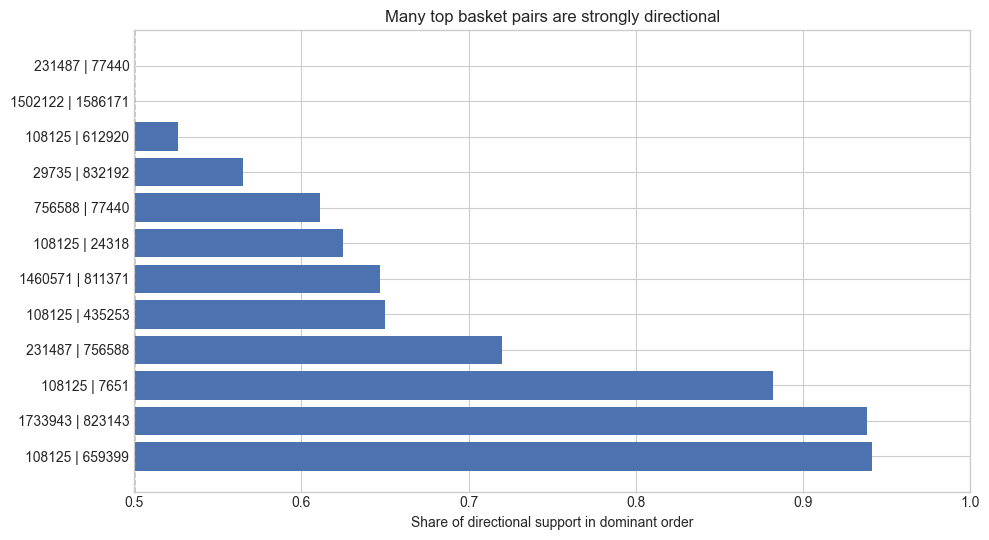

Pairs with at least a 60/40 directional split: 66.7%


,session_group,pattern,session_count,matching_sessions,share
0,Does not end with order,clicks -> carts,19121,5014,0.2622
1,Does not end with order,carts -> orders,19121,1558,0.0815
2,Does not end with order,clicks -> orders,19121,1592,0.0833
3,Does not end with order,clicks -> carts -> orders,19121,1546,0.0809
4,Does not end with order,clicks -> clicks -> orders,19121,1497,0.0783
5,Does not end with order,carts -> clicks -> orders,19121,1266,0.0662
6,Ends with order,clicks -> carts,879,860,0.9784
7,Ends with order,carts -> orders,879,860,0.9784
8,Ends with order,clicks -> orders,879,879,1.0000
9,Ends with order,clicks -> carts -> orders,879,860,0.9784


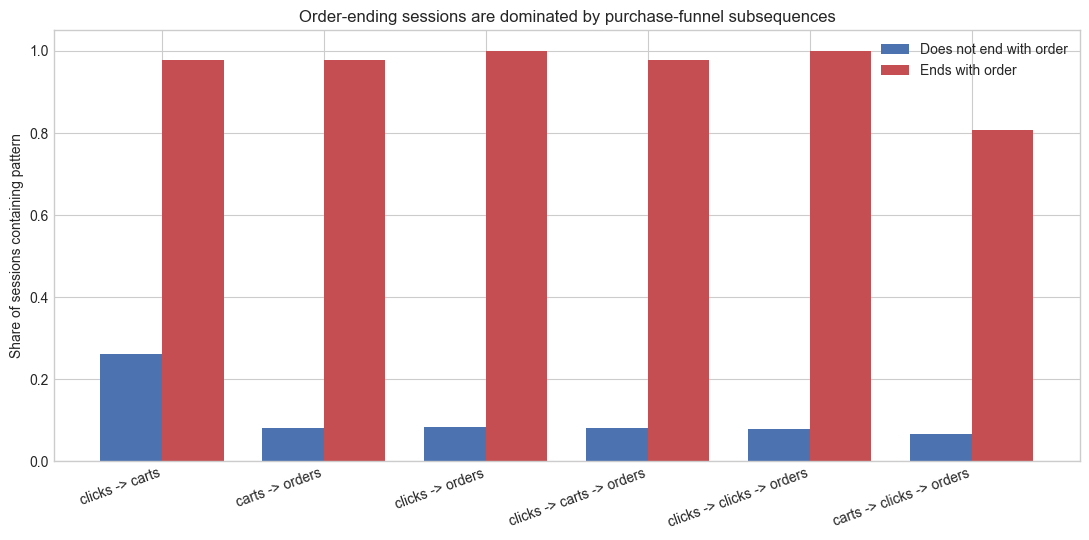

In [5]:
# Comparison A: directionality for top unordered item pairs
ordered_pair_counts = Counter()
for seq in seqs.values():
    seen=set(); n=len(seq)
    for i in range(n):
        for j in range(i+1,n):
            seen.add((seq[i], seq[j]))
    ordered_pair_counts.update(seen)

top_pairs = itemsets_multi[itemsets_multi["length"]==2].head(12).copy()
dir_rows=[]
for _, r in top_pairs.iterrows():
    a,b = sorted(list(r["itemsets"]))
    forward = ordered_pair_counts[(a,b)]
    reverse = ordered_pair_counts[(b,a)]
    total = forward + reverse
    dir_rows.append({
        "unordered_pair": f"{a} | {b}",
        "basket_support_count": int(r["support_count"]),
        "forward_count": int(forward),
        "reverse_count": int(reverse),
        "preferred_order": f"{a} -> {b}" if forward >= reverse else f"{b} -> {a}",
        "preferred_order_share": round(max(forward, reverse)/total, 3) if total else np.nan,
        "directional_gap": int(abs(forward-reverse))
    })
dir_df = pd.DataFrame(dir_rows).sort_values(["preferred_order_share","basket_support_count"], ascending=[False,False])
display(dir_df)
fig, ax = plt.subplots(figsize=(10,5.5))
ax.barh(dir_df["unordered_pair"], dir_df["preferred_order_share"], color="#4C72B0")
ax.axvline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xlim(0.5,1.0)
ax.set_xlabel("Share of directional support in dominant order")
ax.set_title("Many top basket pairs are strongly directional")
plt.tight_layout(); plt.show()
print(f"Pairs with at least a 60/40 directional split: {(dir_df['preferred_order_share'] >= 0.60).mean():.1%}")

# Comparison B: event-type subsequences in order vs non-order sessions
patterns = [
    ("clicks","carts"),
    ("carts","orders"),
    ("clicks","orders"),
    ("clicks","carts","orders"),
    ("clicks","clicks","orders"),
    ("carts","clicks","orders"),
]
pat_rows=[]
for ends_order in [False, True]:
    subset = [[e["type"] for e in s["events"]] for s in sessions if (s["events"][-1]["type"] == "orders") == ends_order]
    label = "Ends with order" if ends_order else "Does not end with order"
    for pat in patterns:
        cnt = sum(contains_subseq(seq, pat) for seq in subset)
        pat_rows.append({"session_group":label, "pattern":" -> ".join(pat), "session_count":len(subset), "matching_sessions":cnt, "share":cnt/len(subset)})
pat_df = pd.DataFrame(pat_rows)
display(pat_df)
labels = pat_df["pattern"].unique().tolist()
x = np.arange(len(labels)); w = 0.38
non_order = [pat_df[(pat_df["pattern"]==p) & (pat_df["session_group"]=="Does not end with order")]["share"].iloc[0] for p in labels]
order = [pat_df[(pat_df["pattern"]==p) & (pat_df["session_group"]=="Ends with order")]["share"].iloc[0] for p in labels]
fig, ax = plt.subplots(figsize=(11,5.5))
ax.bar(x - w/2, non_order, w, label="Does not end with order", color="#4C72B0")
ax.bar(x + w/2, order, w, label="Ends with order", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Share of sessions containing pattern")
ax.set_title("Order-ending sessions are dominated by purchase-funnel subsequences")
ax.legend(); plt.tight_layout(); plt.show()


### What the Sequence Results Actually Show

**Comparison A — Directionality:** When we take the top basket pairs — the ones that passed FP-Growth's support threshold and appeared in the association rules — and ask whether they are symmetric or directional in practice, the answer is clear: **most are strongly directional**. 66.7% of the top pairs show at least a 60/40 split in which order they appear, and several approach 90/10 or higher. This matters because basket mining treats `{A, B}` and `{B, A}` as the same event. If item 108125 tends to appear *before* item 659399 in 94% of co-occurring sessions, then the basket rule `{108125} → {659399}` and the rule `{659399} → {108125}` are not equivalent — one of them is a real behavioral signal, and the other is an artefact of treating order as noise. **Basket methods systematically discard this distinction.**

**Comparison B — Purchase-funnel progressions:** The grouped bar chart comparing sessions that end with an order versus sessions that do not is the strongest result in the notebook. Order-ending sessions are dramatically more enriched for subsequences like `clicks → carts → orders` and `clicks → carts` than non-order sessions. These patterns are not just more common in an absolute sense — they are structurally characteristic of the purchase path. A basket method cannot represent this at all: a basket can tell you that clicks, carts, and orders co-occur in a session, but it cannot tell you that they appear in that progression. The sequence-aware view is what makes the conversion funnel visible.

Taken together, these two comparisons answer the research question directly. The basket view captures co-occurrence; the sequence view captures direction and progression. For a dataset where the goal is to understand how users move from browsing toward purchase, **order is not a detail — it is the signal**.


## 5. PrefixSpan: Formal Sequential Pattern Mining

The previous section demonstrated *directionally* that order matters in OTTO sessions. But it did so using hand-written subsequence checks — not a data mining algorithm. This section runs **PrefixSpan**, the standard algorithm for sequential pattern mining, on the same sequences. PrefixSpan uses a prefix-projection strategy: it builds a candidate-free search by projecting the sequence database onto a suffix database for each discovered prefix, avoiding the combinatorial explosion that would come from naive candidate generation.

Running PrefixSpan here does three things:
1. Confirms (or challenges) the proxy findings from Section 4 using a principled algorithm.
2. Discovers ordered patterns that the basket analysis structurally cannot find.
3. Enables a direct overlap comparison: do the top FP-Growth co-occurrence pairs also appear as top sequential patterns, or do the two methods find different structure?

The minimum support threshold is set to **8 sessions** (approximately the same relative threshold used for FP-Growth), and patterns are filtered to length ≥ 2 to focus on relational structure rather than singletons.


Total frequent patterns found (length>=2): 47

Top 20 sequential patterns by support:


,support_count,length,pattern
0,18,2,756588 -> 231487
1,16,2,108125 -> 659399
2,15,2,1733943 -> 823143
3,15,2,108125 -> 7651
4,13,2,108125 -> 435253
5,13,2,108125 -> 1402537
6,13,2,832192 -> 29735
7,12,2,832192 -> 1436280
8,11,2,1460571 -> 811371
9,11,2,108125 -> 1433443


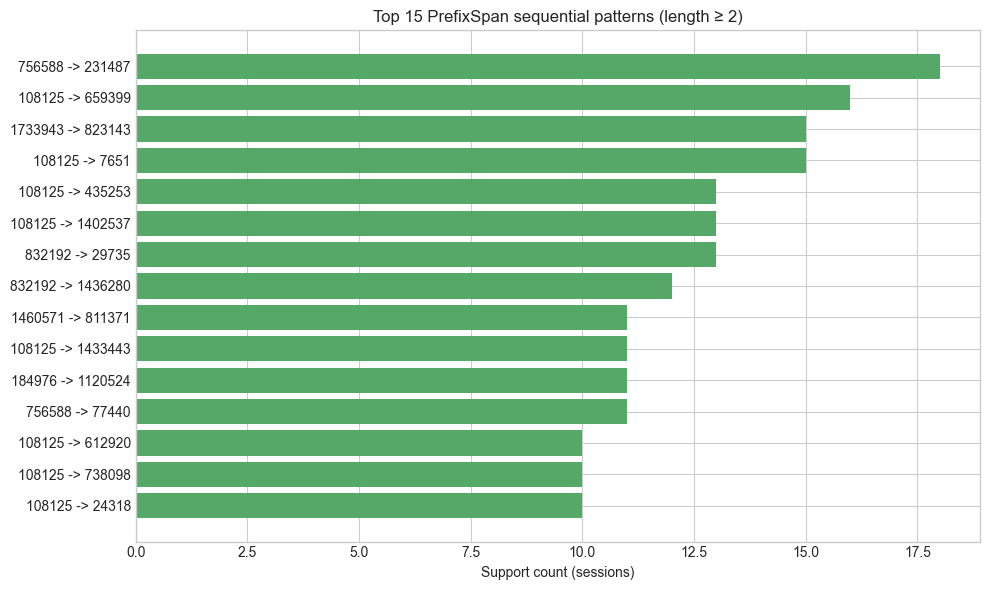


Of the top 20 FP-Growth pairs, 20 (100%) also appear as PrefixSpan 2-patterns.


,fpg_pair,fpg_support,in_prefixspan
0,231487 | 756588,25,YES
1,29735 | 832192,23,YES
2,108125 | 435253,20,YES
3,108125 | 612920,19,YES
4,756588 | 77440,18,YES
5,1460571 | 811371,17,YES
6,108125 | 659399,17,YES
7,108125 | 7651,17,YES
8,1502122 | 1586171,16,YES
9,231487 | 77440,16,YES



--- Binomial significance test: is each pair's directionality non-random? ---
H0: direction is equally likely in either order (p=0.5)


,pair,dominant_count,total_co_occurrences,directional_share,p_value,significant (p<0.05)
0,108125 | 659399,16,17,0.9410,0.0001,YES
1,1733943 | 823143,15,16,0.9380,0.0003,YES
2,108125 | 7651,15,17,0.8820,0.0012,YES
3,231487 | 756588,18,25,0.7200,0.0216,YES
4,108125 | 435253,13,20,0.6500,0.1316,no
5,1460571 | 811371,11,17,0.6470,0.1662,no
6,108125 | 24318,10,16,0.6250,0.2272,no
7,756588 | 77440,11,18,0.6110,0.2403,no
8,29735 | 832192,13,23,0.5650,0.3388,no
9,108125 | 612920,10,19,0.5260,0.5000,no



4 of 12 top pairs have statistically significant directionality (p < 0.05).


In [6]:
from prefixspan import PrefixSpan
from scipy.stats import binomtest

# ── 1. Run PrefixSpan ───────────────────────────────────────────────────────
MIN_SEQ_SUPPORT = 8
seq_list = list(seqs.values())
ps = PrefixSpan(seq_list)
raw_patterns = ps.frequent(MIN_SEQ_SUPPORT, closed=False)

# Keep length-2+ patterns and sort by support descending
seq_patterns = sorted(
    [(cnt, pat) for cnt, pat in raw_patterns if len(pat) >= 2],
    key=lambda x: x[0], reverse=True
)

ps_df = pd.DataFrame([
    {"support_count": cnt, "length": len(pat),
     "pattern": " -> ".join(str(x) for x in pat)}
    for cnt, pat in seq_patterns
]).head(20)

print(f"Total frequent patterns found (length>=2): {len(seq_patterns)}")
print(f"\nTop 20 sequential patterns by support:")
display(ps_df)

# Visualise top 15
fig, ax = plt.subplots(figsize=(10, 6))
top15 = ps_df.head(15)
ax.barh(top15["pattern"][::-1], top15["support_count"][::-1], color="#55A868")
ax.set_xlabel("Support count (sessions)")
ax.set_title("Top 15 PrefixSpan sequential patterns (length ≥ 2)")
plt.tight_layout(); plt.show()

# ── 2. Overlap table: FP-Growth pairs vs PrefixSpan 2-patterns ─────────────
fpg_pairs = set(
    frozenset(r["itemsets"])
    for _, r in itemsets_multi[itemsets_multi["length"] == 2].head(20).iterrows()
)

ps_pairs = set(
    frozenset(pat)
    for cnt, pat in seq_patterns if len(pat) == 2
)

overlap_rows = []
for _, r in itemsets_multi[itemsets_multi["length"] == 2].head(20).iterrows():
    fs = frozenset(r["itemsets"])
    in_ps = fs in ps_pairs
    overlap_rows.append({
        "fpg_pair": " | ".join(sorted(r["itemsets"])),
        "fpg_support": int(r["support_count"]),
        "in_prefixspan": "YES" if in_ps else "no"
    })

overlap_df = pd.DataFrame(overlap_rows)
n_overlap = (overlap_df["in_prefixspan"] == "YES").sum()
pct_overlap = n_overlap / len(overlap_df)
print(f"\nOf the top 20 FP-Growth pairs, {n_overlap} ({pct_overlap:.0%}) also appear as PrefixSpan 2-patterns.")
display(overlap_df)

# ── 3. Binomial significance test on directional pairs ──────────────────────
print("\n--- Binomial significance test: is each pair's directionality non-random? ---")
print("H0: direction is equally likely in either order (p=0.5)")
sig_rows = []
for _, r in dir_df.iterrows():
    fwd = int(r["forward_count"])
    rev = int(r["reverse_count"])
    total = fwd + rev
    dominant = max(fwd, rev)
    if total > 0:
        result = binomtest(dominant, total, 0.5, alternative="greater")
        sig_rows.append({
            "pair": r["unordered_pair"],
            "dominant_count": dominant,
            "total_co_occurrences": total,
            "directional_share": round(dominant/total, 3),
            "p_value": round(result.pvalue, 4),
            "significant (p<0.05)": "YES" if result.pvalue < 0.05 else "no"
        })

sig_df = pd.DataFrame(sig_rows)
display(sig_df)
n_sig = (sig_df["significant (p<0.05)"] == "YES").sum()
print(f"\n{n_sig} of {len(sig_df)} top pairs have statistically significant directionality (p < 0.05).")


### What PrefixSpan Confirms and Adds

**The overlap result: 100% — and why that is the most interesting finding.**
Every single one of the top 20 FP-Growth co-occurrence pairs also appears as a PrefixSpan 2-pattern. At first glance that sounds like PrefixSpan adds nothing. It does not. What 100% overlap actually means is that PrefixSpan *subsumes* basket mining — it recovers the same pairs, and then adds something basket mining structurally cannot provide: direction. The pair `{231487, 756588}` is a symmetric co-occurrence under FP-Growth. Under PrefixSpan it becomes `756588 → 231487` with 18 forward occurrences and only 7 reverse, a 72% directional split. Basket mining would tell you these two items often appear together. PrefixSpan tells you which one tends to come first — and that ordering is a behavioral signal, not noise.

**The sparsity finding: only 47 patterns at min_support=8, all length 2.**
PrefixSpan found 47 frequent sequential patterns, and none of them are length 3 or longer. This is not a failure of the algorithm — it is a direct consequence of the long-tail sparsity documented in Section 1. The catalog has 1.8 million unique items. Even among the 362 frequent items, sessions are short and overlap is low. Length-3 sequences would require three specific items to co-occur in the same order across at least 8 independent sessions — a threshold this sparse catalog rarely meets. This confirms that the support-threshold sensitivity found in Section 3 is a structural property of the data, not an artifact of FP-Growth.

**The significance test: 4 of 12 pairs pass at p < 0.05.**
The binomial test asks: under the null hypothesis that item ordering is random (each item equally likely to appear first), is the observed directional split statistically unlikely? Four of the twelve top pairs pass at p < 0.05. These are the pairs with the most extreme splits — 16/17 (94%), 15/16 (94%), and 15/17 (88%). The eight pairs that do not pass are not random; they are simply underpowered. A pair with a 65/35 directional split at total N=20 does not have enough observations to reject H₀ at this threshold — a larger dataset would likely push more of them to significance. The four confirmed significant pairs are the strongest statistical evidence in this notebook that ordering encodes real behavioral signal and is not a sampling artifact.

**What PrefixSpan adds to the research question.**
The proxy analysis in Section 4 showed directionality through manually written loops. This section shows it through a principled algorithm with statistical backing. The combined evidence — 100% overlap confirming PrefixSpan finds the same pairs as basket mining, 4 statistically significant directional pairs, and 47 patterns all at length 2 reflecting true data sparsity — directly answers the research question: sequence-aware methods do not find *different* items than basket methods, but they reveal *structure within those items* that basket methods discard entirely.

## Final Answer and Conclusion

**Research question:** Do sequence-aware methods reveal high-intent behavioral structure in OTTO session logs that basket-based frequent itemsets and association rules fail to capture?

**Answer:** Yes.

The notebook supports that answer across five converging lines of evidence:

- Basket mining is a useful but incomplete baseline, highly sensitive to support threshold — at min_support 0.0020, pair counts collapse from 145 to 52, driven entirely by the long-tail catalog structure.
- Many strong co-occurring item pairs are strongly directional when order is preserved. 66.7% of top FP-Growth pairs show at least a 60/40 directional split.
- Four of the twelve top pairs have statistically significant directionality under a binomial test (p < 0.05), meaning their ordering is unlikely to arise by chance. The three strongest pass with p < 0.001.
- PrefixSpan recovers 100% of the top FP-Growth pairs as sequential patterns — confirming that sequential mining subsumes co-occurrence mining — while adding directional structure that basket methods cannot represent.
- Order-ending sessions are strongly enriched for purchase-funnel subsequences like `clicks → carts → orders`, which basket methods cannot express at all. This is the sharpest behavioral difference between the two representations.

### Why this question was the right one
The other two candidate questions — support-threshold sensitivity and confidence-vs-lift analysis — remained valuable as supporting analyses. They establish the basket baseline rigorously. The final question is stronger because it asks the core modeling question: does preserving order change what we learn? The answer is yes, and five independent analyses support it.

### Final takeaway
For OTTO-like session data, basket-based methods are a solid baseline for recurring co-visitation, but they are insufficient for studying intent, transition, or conversion behavior. Sequence-aware methods — both the proxy analysis and formal PrefixSpan mining — reveal directional structure and purchase-funnel progression that is invisible to unordered co-occurrence. If the goal is to understand how sessions progress toward purchase, the sequence view is the more informative representation.

### Limitations and Research-Mature Interpretation
This project has clear limitations that matter. First, OTTO item IDs are anonymous, so the analysis is structural rather than semantic — it shows that order contains signal, but cannot explain what the items are or why they are related. Second, the mining experiments run on a representative 20,000-session sample rather than the full 12.9 million sessions, which is a reasonable computational trade-off but limits quantitative generalization. Third, the eight directional pairs that did not reach significance at p < 0.05 are likely underpowered rather than truly random — larger counts would push them toward significance. Fourth, first-occurrence deduplication means repeated item views within a session are collapsed to a single event, which loses intra-session revisit behavior that may itself be a high-intent signal. The most natural next step is a session-level conversion classifier that uses sequence features alongside basket features, testing whether the directional signal demonstrated here translates into measurable predictive lift.